In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("mabel.txt", header = None, on_bad_lines='skip', encoding = 'utf8')

In [8]:
df.head()

,0,1
0,05/12/19,1:42 pm - Messages to this chat and calls are...
1,05/12/19,1:42 pm - Mabel Infoziant: Hi this is Mabel w...
2,05/12/19,1:42 pm - Mabel Infoziant: What’s your full name
3,05/12/19,1:42 pm - AR❤: Ramisha Rani K
4,05/12/19,1:42 pm - Mabel Infoziant: Ok


In [9]:
df = df.drop(0)
df.columns = ['Date', 'chat']
message = df['chat'].str.split("-", n=1, expand =True)
df["Time"] = message[0]
message1 = message[1].str.split(":", n=1, expand = True)
df["Name"]= message1[0]
df["chat"]=message1[1]
df = df[["Date", "Time", "Name", "chat"]]
df.head()

,Date,Time,Name,chat
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K
4,05/12/19,1:42 pm,Mabel Infoziant,Ok
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 1 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    50 non-null     str  
 1   Time    50 non-null     str  
 2   Name    50 non-null     str  
 3   chat    50 non-null     str  
dtypes: str(4)
memory usage: 1.7 KB


# Sentimental Analysis

In [11]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [12]:
data = df

In [13]:
data.dropna(inplace = True)

In [14]:
sid = SentimentIntensityAnalyzer()

In [16]:
senti = sid.polarity_scores(data['chat'][4])

In [17]:
senti['compound']

0.296

In [18]:
def sentimentalAnalysis(data,columnname):
    import matplotlib.pyplot as plt
    import seaborn as sns

    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    sid = SentimentIntensityAnalyzer()

    data.dropna(inplace=True)

    data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
    data['compound'] = data['scores'].apply(lambda score_dict: score_dict ['compound'])
    data['neg'] = data['scores'].apply(lambda score_dict: score_dict ['neg'])
    data['pos'] = data['scores'].apply(lambda score_dict: score_dict ['pos'])
    data['neu'] = data['scores'].apply(lambda score_dict: score_dict ['neu'])


    data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >= 0 else 'neg')
    plt.clf()

    posneg = pd.DataFrame(data['comp_score'].value_counts())

    return posneg,data

In [19]:
pos,data_Senti=sentimentalAnalysis(data,columnname = 'chat')

<Figure size 640x480 with 0 Axes>

In [20]:
data_Senti

,Date,Time,Name,chat,scores,compound,neg,pos,neu,comp_score
1,05/12/19,1:42 pm,Mabel Infoziant,Hi this is Mabel we just spoke,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,05/12/19,1:42 pm,Mabel Infoziant,What’s your full name,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,05/12/19,1:42 pm,AR❤,Ramisha Rani K,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,05/12/19,1:42 pm,Mabel Infoziant,Ok,"{'neg': 0.0, 'neu': 0.0, 'pos': 1.0, 'compound...",0.2960,0.000,1.000,0.000,pos
5,05/12/19,1:42 pm,Mabel Infoziant,ramisharanik@gmail.com,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,05/12/19,1:43 pm,Mabel Infoziant,Your email Id?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,05/12/19,1:43 pm,AR❤,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.000,0.730,0.270,pos
8,05/12/19,1:43 pm,Mabel Infoziant,I will send 2 abstracts for u to start working,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,05/12/19,1:43 pm,AR❤,Yeah mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
10,05/12/19,1:43 pm,Mabel Infoziant,Give me the list that u have too,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos


In [21]:
pos

,count
comp_score,
pos,48
neg,2


# Topic Modeling 

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_df = 0.95, min_df = 2, stop_words = 'english')
dtm = tfidf.fit_transform(df['chat'])

In [23]:
from sklearn.decomposition import NMF
nmf_model = NMF(n_components = 5, random_state = 42)
nmf_model.fit(dtm)

,"n_components n_components: int or {'auto'} or None, default='auto'Number of components. If `None`, all features are kept.If `n_components='auto'`, the number of components is automatically inferredfrom W or H shapes... versionchanged:: 1.4 Added `'auto'` value... versionchanged:: 1.6 Default value changed from `None` to `'auto'`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneUsed for initialisation (when ``init`` == 'nndsvdar' or'random'), and in Coordinate Descent. Pass an int for reproducibleresults across multiple function calls.See :term:`Glossary <random_state>`.",42
,"init init: {'random', 'nndsvd', 'nndsvda', 'nndsvdar', 'custom'}, default=NoneMethod used to initialize the procedure.Valid options:- `None`: 'nndsvda' if n_components <= min(n_samples, n_features), otherwise random.- `'random'`: non-negative random matrices, scaled with: `sqrt(X.mean() / n_components)`- `'nndsvd'`: Nonnegative Double Singular Value Decomposition (NNDSVD) initialization (better for sparseness)- `'nndsvda'`: NNDSVD with zeros filled with the average of X (better when sparsity is not desired)- `'nndsvdar'` NNDSVD with zeros filled with small random values (generally faster, less accurate alternative to NNDSVDa for when sparsity is not desired)- `'custom'`: Use custom matrices `W` and `H` which must both be provided... versionchanged:: 1.1 When `init=None` and n_components is less than n_samples and n_features defaults to `nndsvda` instead of `nndsvd`.",None
,"solver solver: {'cd', 'mu'}, default='cd'Numerical solver to use:- 'cd' is a Coordinate Descent solver.- 'mu' is a Multiplicative Update solver... versionadded:: 0.17 Coordinate Descent solver... versionadded:: 0.19 Multiplicative Update solver.",'cd'
,"beta_loss beta_loss: float or {'frobenius', 'kullback-leibler', 'itakura-saito'}, default='frobenius'Beta divergence to be minimized, measuring the distance between Xand the dot product WH. Note that values different from 'frobenius'(or 2) and 'kullback-leibler' (or 1) lead to significantly slowerfits. Note that for beta_loss <= 0 (or 'itakura-saito'), the inputmatrix X cannot contain zeros. Used only in 'mu' solver... versionadded:: 0.19",'frobenius'
,"tol tol: float, default=1e-4Tolerance of the stopping condition.",0.0001
,"max_iter max_iter: int, default=200Maximum number of iterations before timing out.",200
,"alpha_W alpha_W: float, default=0.0Constant that multiplies the regularization terms of `W`. Set it to zero(default) to have no regularization on `W`... versionadded:: 1.0",0.0
,"alpha_H alpha_H: float or ""same"", default=""same""Constant that multiplies the regularization terms of `H`. Set it to zero tohave no regularization on `H`. If ""same"" (default), it takes the same value as`alpha_W`... versionadded:: 1.0",'same'
,"l1_ratio l1_ratio: float, default=0.0The regularization mixing parameter, with 0 <= l1_ratio <= 1.For l1_ratio = 0 the penalty is an elementwise L2 penalty(aka Frobenius Norm).For l1_ratio = 1 it is an elementwise L1 penalty.For 0 < l1_ratio < 1, the penalty is a combination of L1 and L2... versionadded:: 0.17 Regularization parameter *l1_ratio* used in the Coordinate Descent solver.",0.0
,"verbose verbose: int, default=0Whether to be verbose.",0


In [24]:
for index,topic in enumerate(nmf_model.components_):
    results = ([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['share', 'soon', 'ask', 'yes', 'sure', 'abstract', 'read', 'kk', 'yeah', 'mam']
['students', 'start', 'yes', 'think', 'sure', 'just', 'send', 'tomorrow', 'mam', 'ok']
['details', 'abstracts', 'start', 'students', 'phone', 'ask', 'office', 'number', 'vignesh', 'send']
['share', 'soon', 'yes', 'mam', 'office', 'know', 'just', 'tomorrow', 'church', 'hi']
['phone', 'know', 'sure', 'share', 'soon', 'meeting', 'details', 'yes', 'need', 'ramisha']


In [25]:
topic_results = nmf_model.transform(dtm)
df['Topic'] = topic_results.argmax(axis = 1)

In [26]:
df["Topic"].value_counts()

Topic
0    22
2    12
4     6
3     5
1     5
Name: count, dtype: int64

# WordCloud

In [27]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud



In [28]:
dataset=df


In [29]:
vv = str(dataset['chat'].iloc[0])

In [30]:
wordcloud = WordCloud(width = 800, height = 800, background_color = 'white').generate(vv)

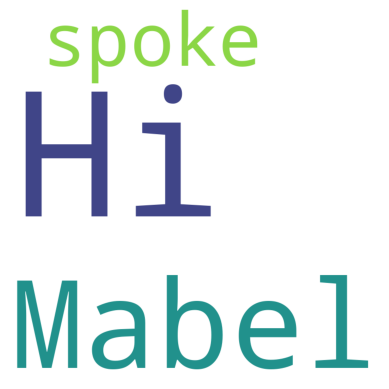

In [31]:
plt.imshow(wordcloud)
plt.axis("off")
plt.show()